In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mental_health_diagnosis_treatment_.csv')

print(df.shape)
print(df.columns.tolist())
df.head()

(500, 17)
['Patient ID', 'Age', 'Gender', 'Diagnosis', 'Symptom Severity (1-10)', 'Mood Score (1-10)', 'Sleep Quality (1-10)', 'Physical Activity (hrs/week)', 'Medication', 'Therapy Type', 'Treatment Start Date', 'Treatment Duration (weeks)', 'Stress Level (1-10)', 'Outcome', 'Treatment Progress (1-10)', 'AI-Detected Emotional State', 'Adherence to Treatment (%)']


,Patient ID,Age,Gender,Diagnosis,Symptom Severity (1-10),Mood Score (1-10),Sleep Quality (1-10),Physical Activity (hrs/week),Medication,Therapy Type,Treatment Start Date,Treatment Duration (weeks),Stress Level (1-10),Outcome,Treatment Progress (1-10),AI-Detected Emotional State,Adherence to Treatment (%)
0,1,43,Female,Major Depressive Disorder,10,5,8,5,Mood Stabilizers,Interpersonal Therapy,2024-01-25,11,9,Deteriorated,7,Anxious,66
1,2,40,Female,Major Depressive Disorder,9,5,4,7,Antipsychotics,Interpersonal Therapy,2024-02-27,11,7,No Change,7,Neutral,78
2,3,55,Female,Major Depressive Disorder,6,3,4,3,SSRIs,Mindfulness-Based Therapy,2024-03-20,14,7,Deteriorated,5,Happy,62
3,4,34,Female,Major Depressive Disorder,6,3,6,5,SSRIs,Mindfulness-Based Therapy,2024-03-29,8,8,Deteriorated,10,Excited,72
4,5,52,Male,Panic Disorder,7,6,6,8,Anxiolytics,Interpersonal Therapy,2024-03-18,12,5,Deteriorated,6,Excited,63


In [16]:
# check for missing values
print(df.isnull().sum())

Patient ID                      0
Age                             0
Gender                          0
Diagnosis                       0
Symptom Severity (1-10)         0
Mood Score (1-10)               0
Sleep Quality (1-10)            0
Physical Activity (hrs/week)    0
Medication                      0
Therapy Type                    0
Treatment Start Date            0
Treatment Duration (weeks)      0
Stress Level (1-10)             0
Outcome                         0
Treatment Progress (1-10)       0
AI-Detected Emotional State     0
Adherence to Treatment (%)      0
dtype: int64


In [17]:
print(df.describe())

       Patient ID         Age  Symptom Severity (1-10)  Mood Score (1-10)  \
count  500.000000  500.000000               500.000000         500.000000   
mean   250.500000   38.708000                 7.478000           5.482000   
std    144.481833   12.712433                 1.706265           1.707486   
min      1.000000   18.000000                 5.000000           3.000000   
25%    125.750000   28.000000                 6.000000           4.000000   
50%    250.500000   38.000000                 8.000000           5.000000   
75%    375.250000   50.000000                 9.000000           7.000000   
max    500.000000   60.000000                10.000000           8.000000   

       Sleep Quality (1-10)  Physical Activity (hrs/week)  \
count            500.000000                    500.000000   
mean               6.472000                      5.216000   
std                1.668167                      2.829374   
min                4.000000                      1.000000   
2

In [18]:
print(f"Min adherence: {df['Adherence to Treatment (%)'].min()}")
print(f"Max adherence: {df['Adherence to Treatment (%)'].max()}")
print(f"Mean: {df['Adherence to Treatment (%)'].mean():.2f}")
print(f"Median: {df['Adherence to Treatment (%)'].median():.2f}")
print(f"Std Dev: {df['Adherence to Treatment (%)'].std():.2f}")
# fairly high adherance across the board
# mean and median being similar -> fairly symmetric distribution

Min adherence: 60
Max adherence: 90
Mean: 75.45
Median: 76.00
Std Dev: 9.09


In [19]:
# histogram bin calculations
n = len(df)

# sturges' rule
sturges = int(np.ceil(np.log2(n) + 1))

# square root rule
sqrt_rule = int(np.ceil(np.sqrt(n)))

print(f"Sturges' Rule: {sturges} bins")
print(f"Square Root Rule: {sqrt_rule} bins")

Sturges' Rule: 10 bins
Square Root Rule: 23 bins


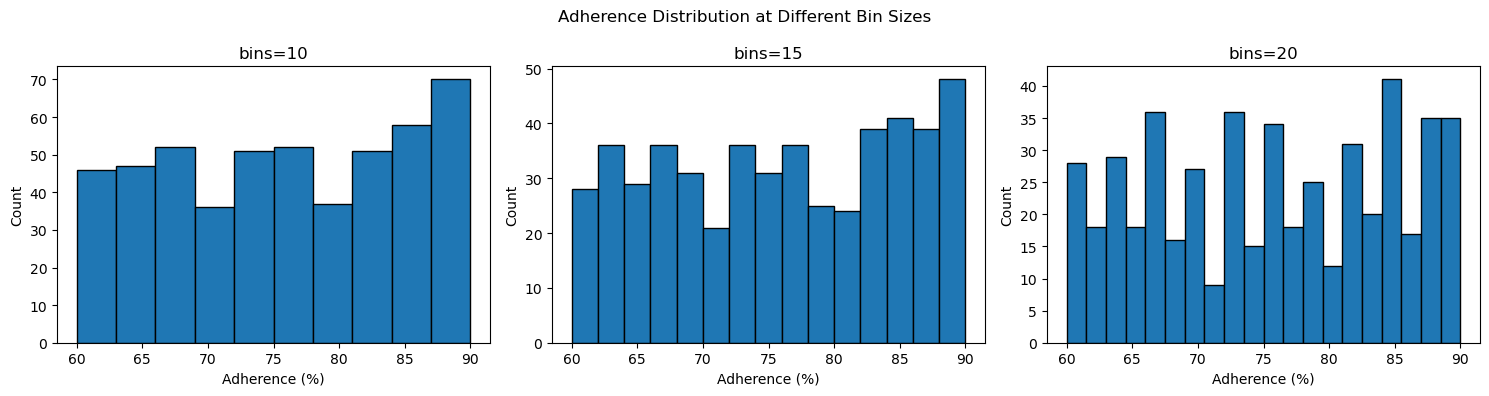

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bin_options = [10, 15, 20]

for ax, bins in zip(axes, bin_options):
    ax.hist(df['Adherence to Treatment (%)'], bins=bins, edgecolor='black')
    ax.set_title(f'bins={bins}')
    ax.set_xlabel('Adherence (%)')
    ax.set_ylabel('Count')

plt.suptitle('Adherence Distribution at Different Bin Sizes')
plt.tight_layout()
plt.savefig('bin_comparison.png')
plt.show()

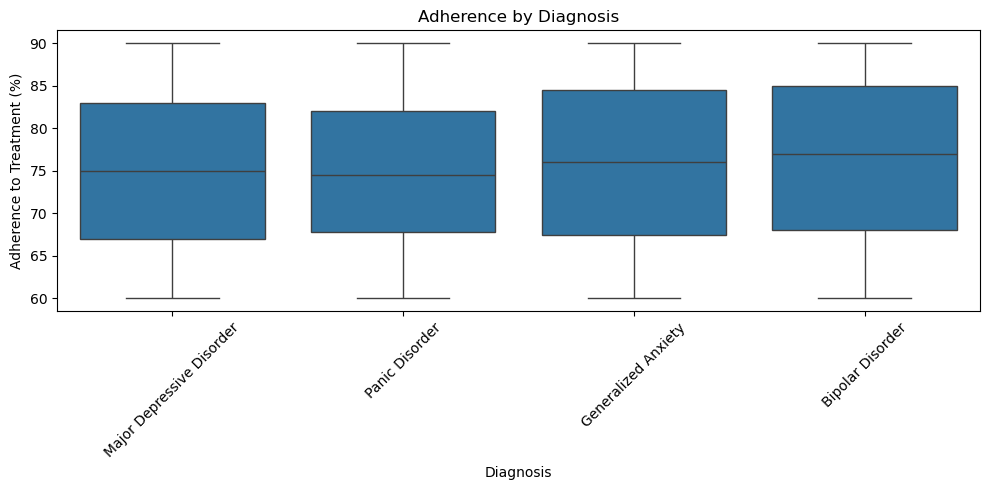

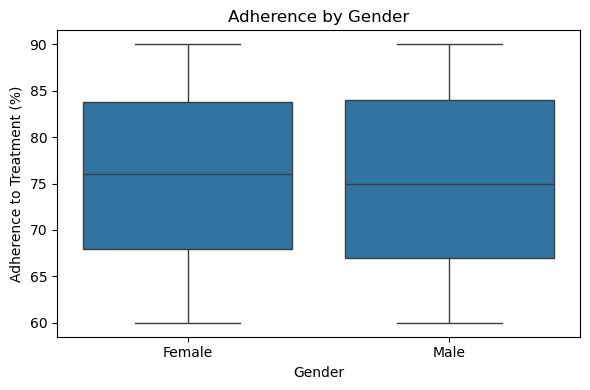

In [21]:
# adherence by diagnosis
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Diagnosis', y='Adherence to Treatment (%)')
plt.xticks(rotation=45)
plt.title('Adherence by Diagnosis')
plt.tight_layout()
plt.show()

# adherence by gender
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Gender', y='Adherence to Treatment (%)')
plt.title('Adherence by Gender')
plt.tight_layout()
plt.show()

In [22]:
# possible adherence threshold choices
# Option A: equal width splits
# Option B: Quantile/percent based splits
    # gives room for more equal number of participants in each class which can be important due to dataset size
t1 = df['Adherence to Treatment (%)'].quantile(0.33)
t2 = df['Adherence to Treatment (%)'].quantile(0.67)

print(f"33rd percentile (Low/Medium boundary): {t1:.1f}")
print(f"67th percentile (Medium/High boundary): {t2:.1f}")

def label_adherence(pct):
    if pct <= t1:
        return 0
    elif pct <= t2:
        return 1
    else:
        return 2

df['Adherence_Class'] = df['Adherence to Treatment (%)'].apply(label_adherence)
print(df['Adherence_Class'].value_counts().sort_index())

33rd percentile (Low/Medium boundary): 70.0
67th percentile (Medium/High boundary): 82.0
Adherence_Class
0    172
1    180
2    148
Name: count, dtype: int64


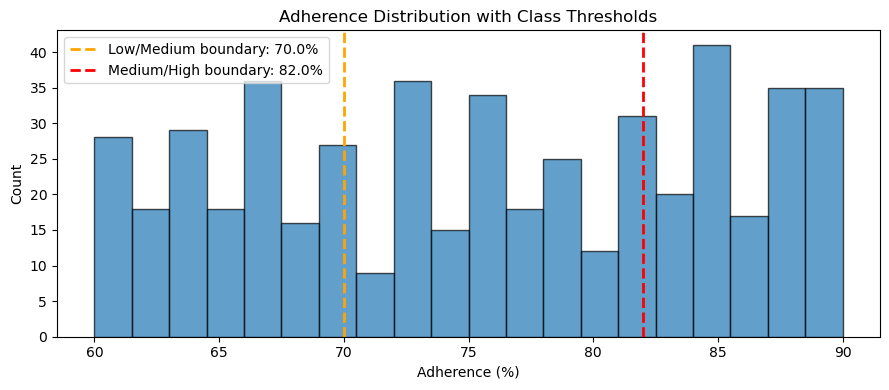

In [23]:
plt.figure(figsize=(9, 4))
plt.hist(df['Adherence to Treatment (%)'], bins=20, edgecolor='black', alpha=0.7)
plt.axvline(t1, color='orange', linewidth=2, linestyle='--', label=f'Low/Medium boundary: {t1:.1f}%')
plt.axvline(t2, color='red', linewidth=2, linestyle='--', label=f'Medium/High boundary: {t2:.1f}%')
plt.title('Adherence Distribution with Class Thresholds')
plt.xlabel('Adherence (%)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('adherence_thresholds.png')
plt.show()

In [24]:
# pre-treatment features
features_to_keep = [
    'Patient ID', 'Age', 'Gender', 'Diagnosis', 'Symptom Severity (1-10)',
    'Medication', 'Therapy Type', 'Stress Level (1-10)',
    'Sleep Quality (1-10)', 'Physical Activity (hrs/week)', 'Treatment Start Date'
]

print(df[features_to_keep].dtypes)

Patient ID                       int64
Age                              int64
Gender                          object
Diagnosis                       object
Symptom Severity (1-10)          int64
Medication                      object
Therapy Type                    object
Stress Level (1-10)              int64
Sleep Quality (1-10)             int64
Physical Activity (hrs/week)     int64
Treatment Start Date            object
dtype: object


In [ ]:
#Feature Encoding and scaling values, done on a copy of the dataset awaiting any modifications 
from sklearn.preprocessing import TargetEncoder
#Drop unnecessary features
features_to_drop = [
    'Treatment Duration (weeks)',
    'Outcome',
    'Treatment Progress (1-10)',
    'AI-Detected Emotional State',
    'Adherence to Treatment (%)',
    'Patient ID'
]
df2= df.copy()
df2.drop(columns= features_to_drop, inplace=True )
# checking unique values in non-numerical columns to decipher encoding methods
print(df2['Medication'].unique())
print(df2['Diagnosis'].unique())
print(df2['Therapy Type'].unique())
# low cardinality features, which call for one-hot encoding
# We want to know how much each of these features contributes to adherence

['Mood Stabilizers' 'Antipsychotics' 'SSRIs' 'Anxiolytics'
 'Antidepressants' 'Benzodiazepines']
['Major Depressive Disorder' 'Panic Disorder' 'Generalized Anxiety'
 'Bipolar Disorder']
['Interpersonal Therapy' 'Mindfulness-Based Therapy'
 'Cognitive Behavioral Therapy' 'Dialectical Behavioral Therapy']


In [73]:
# Encode non-numerical features 
# Convert 'Treatment Start Date' to flat integer 'Treatment Days' which aims to 
# capture the significance of treatment dates to predicting adherence
# Simple conversion allows comparability to other numeric features
df2['Treatment Start Date'] = pd.to_datetime(df2['Treatment Start Date'])
df2['Treatment Days'] = (df2['Treatment Start Date'] - df2['Treatment Start Date'].min()).dt.days
df2.drop('Treatment Start Date', axis=1, inplace=True)

# Use one-hot encoding for nominal variables without ordinal significance
df2 = pd.get_dummies(df2, columns=['Gender', 'Therapy Type', 'Diagnosis', 'Medication'], drop_first=True)
df2 = df2.astype({col: int for col in df2.select_dtypes('bool').columns})

display(df2)

# Next Steps: Scaling and splitting the data for model training
# Plan to standardize feature values
# Plan to partition data into training and testing sets
# Plan to apply percentage based thresholding

,Age,Symptom Severity (1-10),Mood Score (1-10),Sleep Quality (1-10),Physical Activity (hrs/week),Stress Level (1-10),Adherence_Class,Treatment Days,Gender_Male,Therapy Type_Dialectical Behavioral Therapy,Therapy Type_Interpersonal Therapy,Therapy Type_Mindfulness-Based Therapy,Diagnosis_Generalized Anxiety,Diagnosis_Major Depressive Disorder,Diagnosis_Panic Disorder,Medication_Antipsychotics,Medication_Anxiolytics,Medication_Benzodiazepines,Medication_Mood Stabilizers,Medication_SSRIs
0,43,10,5,8,5,9,0,24,0,0,1,0,0,1,0,0,0,0,1,0
1,40,9,5,4,7,7,1,57,0,0,1,0,0,1,0,1,0,0,0,0
2,55,6,3,4,3,7,0,79,0,0,0,1,0,1,0,0,0,0,0,1
3,34,6,3,6,5,8,1,88,0,0,0,1,0,1,0,0,0,0,0,1
4,52,7,6,6,8,5,0,77,1,0,1,0,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,24,10,4,8,6,9,1,99,1,1,0,0,1,0,0,0,0,0,1,0
496,22,5,6,6,7,6,2,35,1,0,0,1,0,0,1,0,0,1,0,0
497,23,7,3,4,2,5,2,83,1,0,0,0,0,1,0,0,0,0,0,0
498,48,9,4,6,9,6,1,81,1,0,0,1,0,0,0,0,0,0,0,0


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Checking for multicollinearity to identify if there are any highly correlated features
X = df2.drop('Adherence_Class', axis=1)

X['intercept'] = 1

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                                        feature         VIF
19                                    intercept  102.629748
18                             Medication_SSRIs    1.846023
14                    Medication_Antipsychotics    1.818476
16                   Medication_Benzodiazepines    1.810341
17                  Medication_Mood Stabilizers    1.800862
15                       Medication_Anxiolytics    1.683539
10       Therapy Type_Mindfulness-Based Therapy    1.632587
9            Therapy Type_Interpersonal Therapy    1.607780
8   Therapy Type_Dialectical Behavioral Therapy    1.587917
12          Diagnosis_Major Depressive Disorder    1.566330
11                Diagnosis_Generalized Anxiety    1.562343
13                     Diagnosis_Panic Disorder    1.539191
3                          Sleep Quality (1-10)    1.048526
7                                   Gender_Male    1.036827
5                           Stress Level (1-10)    1.036490
2                             Mood Score